# ОСНОВНАЯ ЧАСТЬ

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

keras.utils.set_random_seed(42)

## Шаг 1. Данные

Используем набор из 40 отзывов: 15 позитивных, 15 негативных, 10 нейтральных.

Для бинарной классификации берём только позитив и негатив, нейтральные понадобятся позже.

In [11]:
# собираем датасет вручную
sentiment_data = {
    "text": [
        # позитив (метка 1)
        "Отличный фильм, очень понравился!",
        "Прекрасная книга, рекомендую всем прочитать.",
        "Качественный товар, доволен покупкой.",
        "Замечательный сервис, быстро и профессионально.",
        "Потрясающий ресторан, вкусная еда и уютная атмосфера.",
        "Великолепный спектакль, получил массу удовольствия.",
        "Отличное приложение, удобный интерфейс.",
        "Прекрасный отель, комфортные номера и хороший завтрак.",
        "Замечательный преподаватель, интересные лекции.",
        "Потрясающая музыка, слушаю постоянно.",
        "Отличный телефон, все работает быстро.",
        "Прекрасный подарок, очень доволен.",
        "Качественный кофе, ароматный и вкусный.",
        "Замечательный парк, красивая природа.",
        "Потрясающий концерт, незабываемые эмоции.",
        "Очень понравился сервис, всё чётко и быстро.",
        "Прекрасное качество, буду заказывать ещё.",
        "Отличная доставка, всё пришло вовремя.",
        "Замечательная атмосфера, приятно провели время.",
        "Потрясающий вид, очень красивое место.",
        "Великолепное блюдо, очень вкусно приготовлено.",
        "Отличный мастер, сделал всё аккуратно.",
        "Прекрасная поездка, всё организовано хорошо.",
        "Замечательный фильм, смотрел с удовольствием.",
        "Потрясающая книга, не мог оторваться.",
        # негатив (метка 0)
        "Ужасный фильм, полная потеря времени.",
        "Плохая книга, скучно и неинтересно.",
        "Низкое качество товара, очень разочарован.",
        "Плохой сервис, долго ждал и ничего не получил.",
        "Отвратительный ресторан, невкусная еда.",
        "Скучный спектакль, не рекомендую.",
        "Плохое приложение, постоянно глючит.",
        "Ужасный отель, грязные номера и плохое обслуживание.",
        "Скучный преподаватель, неинтересные лекции.",
        "Плохая музыка, не понравилась.",
        "Плохой телефон, постоянно зависает.",
        "Разочаровался в подарке, не то что ожидал.",
        "Плохой кофе, безвкусный и холодный.",
        "Запущенный парк, грязно и неухоженно.",
        "Скучный концерт, не оправдал ожиданий.",
        "Ужасное обслуживание, грубые сотрудники.",
        "Плохое качество, сломалось через день.",
        "Отвратительная доставка, ждал две недели.",
        "Ужасная атмосфера, шумно и некомфортно.",
        "Плохое место, грязно и неприятно.",
        "Отвратительное блюдо, невозможно есть.",
        "Плохой мастер, сделал всё криво.",
        "Ужасная поездка, всё пошло не так.",
        "Разочаровал фильм, скучный и затянутый.",
        "Плохая книга, бросил на середине.",
        # нейтрал (метка 2) - используем в бонусе
        "Обычный фильм, ничего особенного.",
        "Стандартная книга, читается нормально.",
        "Обычный товар, соответствует описанию.",
        "Нормальный сервис, без особых претензий.",
        "Обычный ресторан, стандартное меню.",
        "Средний спектакль, можно посмотреть.",
        "Обычное приложение, работает как надо.",
        "Стандартный отель, без изысков.",
        "Обычный преподаватель, стандартные лекции.",
        "Средняя музыка, ничего особенного.",
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
    ]
}

df = pd.DataFrame(sentiment_data)

print(f"Всего отзывов: {len(df)}")
print(df["sentiment"].value_counts().sort_index().rename({0: "негатив", 1: "позитив", 2: "нейтрал"}))

Всего отзывов: 60
sentiment
негатив    25
позитив    25
нейтрал    10
Name: count, dtype: int64


## Шаг 2. Векторизация (TF-IDF)

Переводим слова в числа.

TF-IDF даёт каждому слову вес - чем слово характернее для этого текста и реже встречается в других, тем вес выше.

In [12]:
# убираем нейтральные, оставляем только позитив и негатив
df_binary = df[df["sentiment"] != 2].copy()

# превращаем тексты в числовые векторы
# max_features=50 - берём 50 самых важных слов и пар слов
# ngram_range=(1,2) - учитываем не только отдельные слова но и пары ('плохой фильм')
vectorizer = TfidfVectorizer(max_features=50, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_binary["text"]).toarray()
y = df_binary["sentiment"].values

# делим на обучающую и тестовую выборки
# stratify=y - сохраняем одинаковое соотношение классов в обеих частях
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# масштабируем признаки - помогает сети быстрее и лучше учиться
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} примеров, Test: {X_test.shape[0]} примеров")
print(f"Признаков: {X_train.shape[1]}")


Train: 35 примеров, Test: 15 примеров
Признаков: 50


## Шаг 3. Модель

Строим сеть из трёх слоёв Dense.
ReLU обнуляет отрицательные значения. Sigmoid на выходе сжимает результат в [0, 1]

Loss показывает насколько сильно ошибается модель. fit() обучает сеть - много раз прогоняет данные и обновляет веса. predict() просто возвращает предсказание, веса не трогает.

In [13]:
# фиксируем seed - теперь результат одинаковый при каждом запуске этой ячейки
keras.utils.set_random_seed(42)

# создаём модель
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),  # выход - вероятность позитива
])

# компилируем: задаём оптимизатор, функцию потерь и метрику
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# обучаем модель
# epochs - сколько раз пройти по всем данным
# batch_size - по сколько примеров за один шаг
# validation_split - 20% обучающих данных используем для проверки в процессе
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=8,
    validation_split=0.2,
    verbose=0,
)

print("Готово")
model.summary()

Готово


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,533 (25.52 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,356 (17.02 KB)

## Шаг 4. Метрики

Precision - из всех кого назвали позитивными, сколько реально позитивные.

Recall - из всех реально позитивных, сколько модель нашла.

F1 - среднее между ними

In [14]:
# predict возвращает вероятности от 0 до 1
# порог 0.5 - если больше, считаем позитивным
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

print(f"F1-score:  {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, zero_division=0):.4f}")

F1-score:  0.3529
Precision: 0.3000
Recall:    0.4286


## Шаг 5. Графики обучения

Смотрим как менялись loss и accuracy по эпохам.

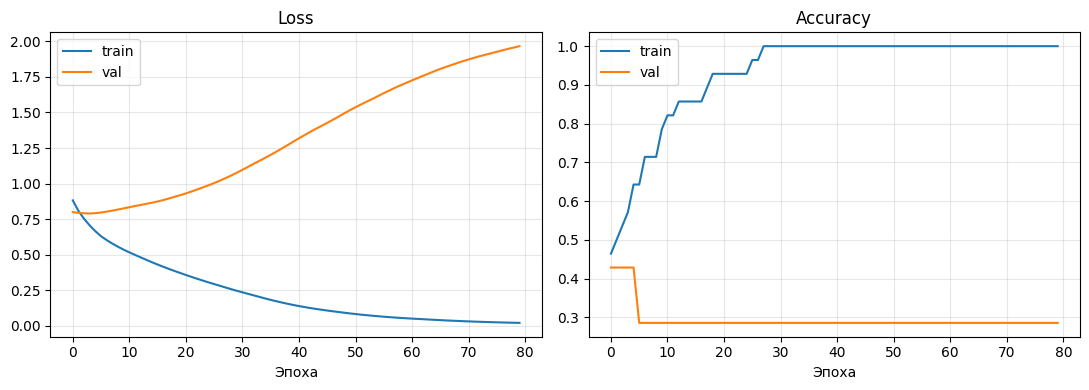

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# ДОПОЛНИТЕЛЬНЫЕ ПУНКТЫ

##  Dropout + Early Stopping

Dropout случайно выключает часть нейронов при обучении

Early Stopping останавливает обучение когда val_loss перестаёт улучшаться, ждём 10 эпох и останавливаемся.

In [16]:
# добавляем Dropout после скрытых слоёв
model_do = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),  # случайно выключаем 30% нейронов
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),  # и ещё 20% перед выходом
    layers.Dense(1, activation="sigmoid"),
])

model_do.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# настраиваем early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,  # возвращаем веса лучшей эпохи
)

# epochs=200, но early stopping остановит раньше
history_do = model_do.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0,
)

print(f"Остановились на эпохе {len(history_do.history['loss'])}")

y_pred_do = (model_do.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print(f"F1 с Dropout + ES: {f1_score(y_test, y_pred_do):.4f}")

Остановились на эпохе 43
F1 с Dropout + ES: 0.4000


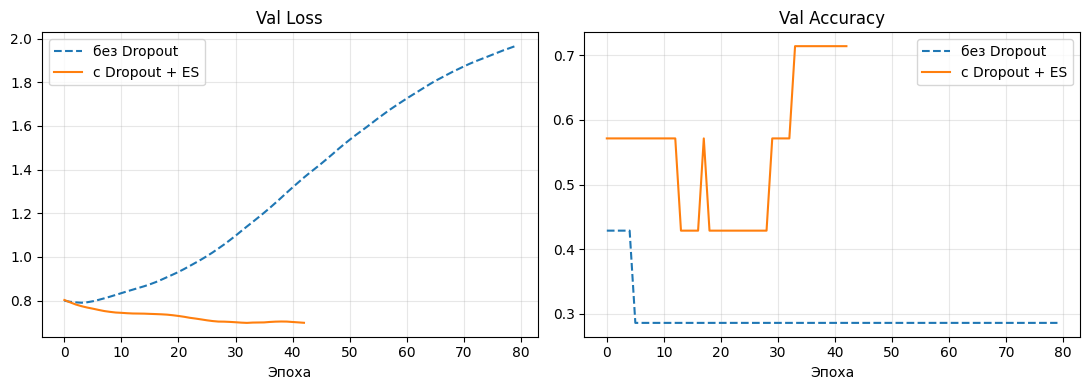

In [17]:
# сравниваем графики базовой модели и модели с Dropout
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["val_loss"], label="без Dropout", linestyle="--")
axes[0].plot(history_do.history["val_loss"], label="с Dropout + ES")
axes[0].set_title("Val Loss")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["val_accuracy"], label="без Dropout", linestyle="--")
axes[1].plot(history_do.history["val_accuracy"], label="с Dropout + ES")
axes[1].set_title("Val Accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Сравнение архитектур

Обучаем три разных модели и сравниваем метрики.

In [18]:
# три архитектуры с разным числом нейронов
# последний элемент всегда 1 - выходной слой
configs = {
    "Маленькая (8)": [8, 1],
    "Средняя (16-8)": [16, 8, 1],
    "Большая (32-16)": [32, 16, 1],
}

results = []

for name, layer_sizes in configs.items():
    m = keras.Sequential()
    m.add(keras.Input(shape=(X_train.shape[1],)))
    # первый скрытый слой
    m.add(layers.Dense(layer_sizes[0], activation="relu"))
    # промежуточные слои если есть
    for size in layer_sizes[1:-1]:
        m.add(layers.Dense(size, activation="relu"))
    # выходной слой
    m.add(layers.Dense(1, activation="sigmoid"))

    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    m.fit(X_train, y_train, epochs=80, batch_size=8, validation_split=0.2, verbose=0)

    y_p = (m.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
    results.append({
        "Архитектура": name,
        "F1": round(f1_score(y_test, y_p, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_p, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_p, zero_division=0), 4),
    })

print(pd.DataFrame(results).to_string(index=False))

    Архитектура     F1  Precision  Recall
  Маленькая (8) 0.4286     0.4286  0.4286
 Средняя (16-8) 0.3750     0.3333  0.4286
Большая (32-16) 0.4286     0.4286  0.4286


На маленьком датасете разница небольшая.

## Forward pass на numpy

Достаём веса из обученной модели и считаем вручную то же самое что делает model.predict().

In [19]:
# достаём матрицу весов W и вектор смещений b из каждого слоя
weights = [layer.get_weights() for layer in model.layers if layer.get_weights()]

def forward_numpy(X, weights):
    out = X
    for i, (W, b) in enumerate(weights):
        out = out @ W + b          # линейное преобразование
        if i < len(weights) - 1:
            out = np.maximum(0, out)               # ReLU для скрытых слоёв
        else:
            out = 1 / (1 + np.exp(-out))           # sigmoid для выходного
    return out

y_numpy = forward_numpy(X_test, weights)
y_keras = model.predict(X_test, verbose=0)

# разница должна быть около 1e-7, то есть практически ноль
print(f"Максимальная разница: {np.max(np.abs(y_numpy - y_keras)):.2e}")

# сравниваем первые 5 предсказаний
print(f"numpy: {y_numpy[:5].flatten().round(4)}")
print(f"keras: {y_keras[:5].flatten().round(4)}")

Максимальная разница: 1.48e-07
numpy: [0.0242 0.6538 0.732  0.9174 0.107 ]
keras: [0.0242 0.6538 0.732  0.9174 0.107 ]
